# Beta-Bernoulli V2

1. Data is from simulation
    - Examine the effect of the size of data set
2. optimize() to get MAT/MLE
3. mcmc by stan

- Bernoulli experiment: $ Y \sim Bernoulli(\theta_\mathrm{true}.7) $
- Prior model: $\theta \sim \mathrm{Beta}(1,1)$
- Posterior (conjugate): $p(\theta \mid Y) = \mathrm{Beta}(\theta \mid \hat\alpha = 1 + N_1, \hat\beta = 1+N_0)$

In [1]:
# Imports and helpers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from math import gamma

## Stan model: Beta-Bernoulli model

In [2]:
# Write Stan model to file
stan_code = r"""
// beta_bernoulli.stan

data {
  int<lower=0> N;                 // number of trials
  array[N] int<lower=0, upper=1> y;     // outcomes
  real<lower=0> alpha0;           // prior alpha
  real<lower=0> beta0;            // prior beta
}

parameters {
  real<lower=0, upper=1> theta;   // success probability
}

model {
  theta ~ beta(alpha0, beta0);    // prior
  y ~ bernoulli(theta);            // likelihood
}
"""

stan_path = Path("beta_bernoulli_v2.stan")
stan_path.write_text(stan_code)
print(f"Wrote Stan model to {stan_path.resolve()}")

Wrote Stan model to C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.stan


## Data Simuation

In [3]:
# Data Simulation
np.random.seed(42)

theta_true = 0.7
N = 10 
Y = np.random.binomial(1, theta_true, size=N)

# prior parameters for Beta distribution
alpha0 = 1.0
beta0 = 1.0

## Sample with cmdstanpy

We compile and sample using cmdstanpy. If CmdStan is not installed, uncomment the install step.


In [4]:
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan
model = CmdStanModel(stan_file=str(stan_path))

data = {
            "N": int(N),
            "y": Y.astype(int).tolist(),
            "alpha0": float(alpha0),
            "beta0": float(beta0),
}

fit = model.sample(data=data, iter_sampling=1000)

theta_samples = fit.stan_variable("theta")

fit.summary()

C:\Users\yongd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
21:51:02 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.stan to exe file C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.exe
21:51:11 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.exe
21:51:11 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█▊        | 00:00 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██████████| 00:00 Sampling completed    


21:51:12 - cmdstanpy - INFO - CmdStan done processing.


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-8.686860,0.018191,0.736289,0.346274,-10.164900,-8.406220,-8.152940,1898.73,2460.91,54249.5,1.00360
theta,0.578937,0.003683,0.139082,0.149230,0.340758,0.584479,0.799139,1425.73,2073.40,40735.2,1.00548


In [5]:
theta_samples.mean(), theta_samples.std()

(0.5789374506849999, 0.13906504338307893)

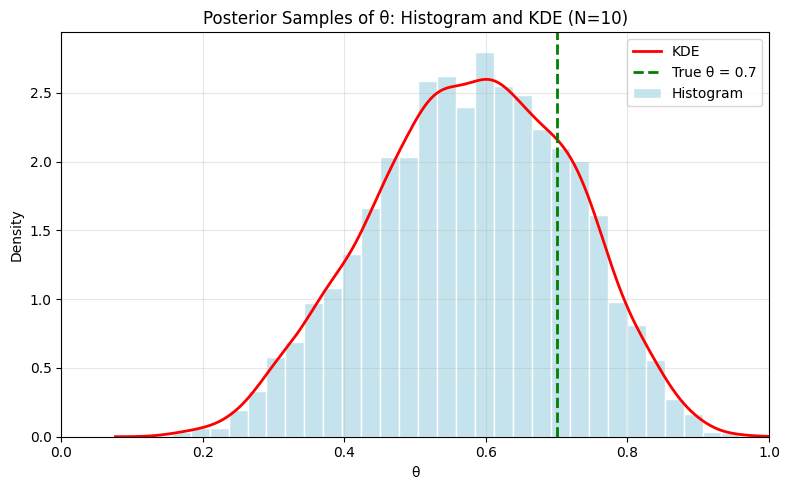

In [6]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples, color="red", linewidth=2, label="KDE")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="--", linewidth=2, label=f"True θ = {theta_true}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## MAP
1. Mode of the posterior if the posterior is $p(\theta|Y) = beta(\theta|\alpha,\beta)$
    $$
        \hat\theta_{MAP} = \frac{\alpha - 1}{\alpha-1 + \beta -1}
    $$

2. Numerical optimization can be used to get approximate estimate:

    `model.optimize(data=data)`


* Since we know the closed-form posterior distribution as a beta distribution, we can compute the two estimates. They should be the same within a numerical accuracy.

In [7]:
result = model.optimize(data=data)
print("theta_hat_MAP:", result.optimized_params_dict.get("theta", None))

21:51:12 - cmdstanpy - INFO - Chain [1] start processing
21:51:12 - cmdstanpy - INFO - Chain [1] done processing


theta_hat_MAP: 0.59999999


---

## Data Simuation: N =  100

In [8]:
# Data Simulation
np.random.seed(42)

theta_true = 0.7
N = 100
Y = np.random.binomial(1, theta_true, size=N)

# prior parameters for Beta distribution
alpha0 = 1.0
beta0 = 1.0

## Sample with cmdstanpy

We compile and sample using cmdstanpy. If CmdStan is not installed, uncomment the install step.


In [9]:
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan
model = CmdStanModel(stan_file=str(stan_path))

data = {
            "N": int(N),
            "y": Y.astype(int).tolist(),
            "alpha0": float(alpha0),
            "beta0": float(beta0),
}

fit100 = model.sample(data=data, iter_sampling=1000)

theta_samples_100 = fit100.stan_variable("theta")

fit100.summary()

21:51:12 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |▍         | 00:00 Status

chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed


21:51:13 - cmdstanpy - INFO - CmdStan done processing.


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-63.111900,0.015994,0.671669,0.279899,-64.53510,-62.845100,-62.645000,2119.09,1978.90,46067.1,1.000400
theta,0.695952,0.001089,0.043745,0.042952,0.62091,0.697921,0.767142,1614.33,1979.75,35094.1,0.999941


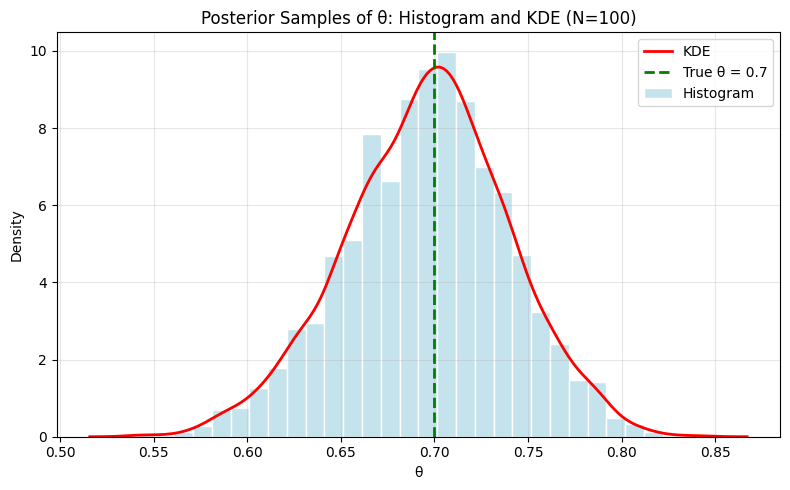

In [10]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples_100, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples_100, color="red", linewidth=2, label="KDE")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="--", linewidth=2, label=f"True θ = {theta_true}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

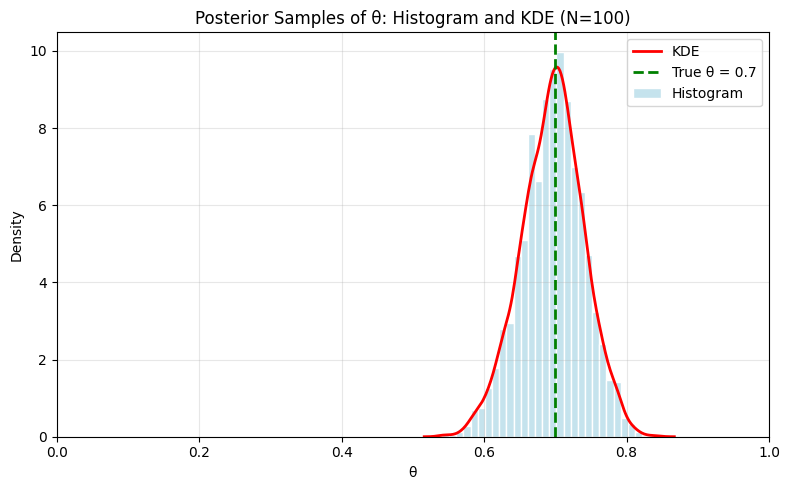

In [11]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples_100, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples_100, color="red", linewidth=2, label="KDE")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="--", linewidth=2, label=f"True θ = {theta_true}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
theta_samples_100.mean(), theta_samples_100.std(), theta_samples.std()/np.sqrt(10)

(0.695951933015, 0.04373962168440283, 0.0439762280000657)

## MAP
1. Mode of the posterior if the posterior is $p(\theta|Y) = beta(\theta|\alpha,\beta)$
    $$
        \hat\theta_{MAP} = \frac{\alpha - 1}{\alpha-1 + \beta -1}
    $$

2. Numerical optimization can be used to get approximate estimate:

    `model.optimize(data=data)`


* Since we know the closed-form posterior distribution as a beta distribution, we can compute the two estimates. They should be the same within a numerical accuracy.

In [13]:
result = model.optimize(data=data)
print("theta_hat_MAP:", result.optimized_params_dict.get("theta", None))

21:51:13 - cmdstanpy - INFO - Chain [1] start processing
21:51:13 - cmdstanpy - INFO - Chain [1] done processing


theta_hat_MAP: 0.69999924


---

## Data Simuation: N =  1000

In [14]:
# Data Simulation
np.random.seed(42)

theta_true = 0.7
N = 1000
Y = np.random.binomial(1, theta_true, size=N)

# prior parameters for Beta distribution
alpha0 = 1.0
beta0 = 1.0

## Sample with cmdstanpy

We compile and sample using cmdstanpy. If CmdStan is not installed, uncomment the install step.


In [15]:
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan
model = CmdStanModel(stan_file=str(stan_path))

data = {
            "N": int(N),
            "y": Y.astype(int).tolist(),
            "alpha0": float(alpha0),
            "beta0": float(beta0),
}

fit1000 = model.sample(data=data, iter_sampling=1000)

theta_samples_1000 = fit1000.stan_variable("theta")

fit1000.summary()

21:51:13 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▍         | 00:00 Status


chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed                     
chain 3 |██████████| 00:00 Sampling completed                     
chain 4 |██████████| 00:00 Sampling completed                     


21:51:13 - cmdstanpy - INFO - CmdStan done processing.


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-602.412000,0.018852,0.680746,0.298529,-603.781000,-602.152000,-601.93700,1565.80,2434.40,34039.2,1.00199
theta,0.711383,0.000374,0.013958,0.013881,0.688881,0.710827,0.73431,1405.88,2033.79,30562.6,1.00168


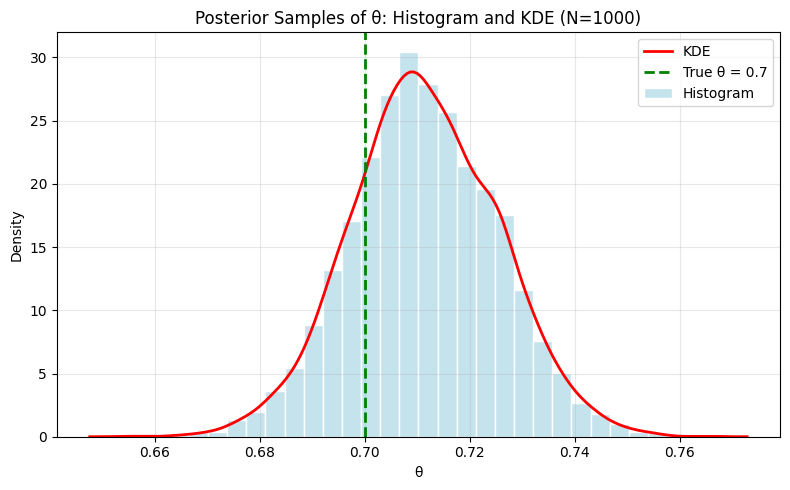

In [16]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples_1000, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples_1000, color="red", linewidth=2, label="KDE")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="--", linewidth=2, label=f"True θ = {theta_true}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

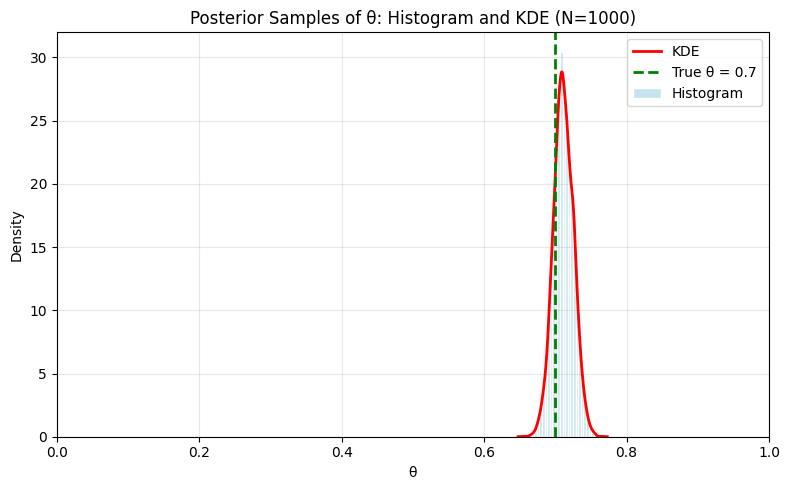

In [17]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples_1000, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples_1000, color="red", linewidth=2, label="KDE")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="--", linewidth=2, label=f"True θ = {theta_true}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [18]:
theta_samples_1000.mean(), theta_samples_1000.std(), theta_samples.std()/np.sqrt(100)

(0.7113829438299999, 0.013955842913359693, 0.013906504338307892)

## MAP
1. Mode of the posterior if the posterior is $p(\theta|Y) = beta(\theta|\alpha,\beta)$
    $$
        \hat\theta_{MAP} = \frac{\alpha - 1}{\alpha-1 + \beta -1}
    $$

2. Numerical optimization can be used to get approximate estimate:

    `model.optimize(data=data)`


* Since we know the closed-form posterior distribution as a beta distribution, we can compute the two estimates. They should be the same within a numerical accuracy.

In [19]:
result = model.optimize(data=data)
print("theta_hat_MAP:", result.optimized_params_dict.get("theta", None))

21:51:14 - cmdstanpy - INFO - Chain [1] start processing
21:51:14 - cmdstanpy - INFO - Chain [1] done processing


theta_hat_MAP: 0.71199995


---
## 📉 General Principle of Uncertainty Reduction

In both **frequentist** and **Bayesian** statistics, the uncertainty (standard deviation or standard error) of parameter estimates typically decreases as the sample size increases. This follows the **inverse square root law**:

### 🔢 Mathematical Form



$$
\text{Uncertainty} \propto \frac{1}{\sqrt{N}}
$$



Where:
- $ N $ is the number of data points (sample size)
- "Uncertainty" refers to standard deviation (Bayesian posterior) or standard error (frequentist estimator)

### 🧠 Why It Happens

- **Frequentist**: The variance of estimators like the sample mean or proportion shrinks with more data.
- **Bayesian**: The posterior distribution becomes more concentrated around the true parameter as data accumulates.

### 📊 Implications

- Doubling the sample size reduces uncertainty by about $ \sqrt{2} $
- Increasing sample size by a factor of 100 reduces uncertainty by a factor of 10

This principle holds broadly across simple and complex models, though the exact rate may vary depending on model structure, priors, and identifiability.
